# 10 — Normalization and Feed-Forward Networks

## Goal

Attention determines how information is exchanged between token
positions, but a Transformer block contains several other important
components.

In this lesson, we study:

- normalization,
- residual connections,
- feed-forward networks,
- nonlinear activations,
- and their organization inside a Transformer block.

The model representation has shape

$$
X \in \mathbb{R}^{B \times T \times C}.
$$

Normalization operates on the feature representation of each token.

Feed-forward networks transform each token independently.

Residual connections allow transformed information to be added back to
the existing representation.

Together with self-attention, these components form the basic structure
of a Transformer block.

In [ ]:
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch
import math

In [48]:
batch_size: int = 2
sequence_length: int = 3
embedding_dim: int = 4

x: torch.Tensor = torch.tensor(
    [
        [
            [1.0, 2.0, 3.0, 4.0],
            [2.0, 4.0, 6.0, 8.0],
            [1.0, 1.0, 1.0, 1.0],
        ],
        [
            [10.0, 20.0, 30.0, 40.0],
            [3.0, 6.0, 9.0, 12.0],
            [-1.0, 0.0, 1.0, 2.0],
        ],
    ]
)

print(x.shape)

torch.Size([2, 3, 4])


## 1. Layer Normalization

For a token representation

$$
x \in \mathbb{R}^{C},
$$

LayerNorm computes the mean

$$
\mu
=
\frac{1}{C}
\sum_{i=1}^{C} x_i
$$

and variance

$$
\sigma^2
=
\frac{1}{C}
\sum_{i=1}^{C}
(x_i-\mu)^2.
$$

The normalized representation is

$$
\hat{x}_i
=
\frac{x_i-\mu}
{\sqrt{\sigma^2+\epsilon}}.
$$

Two learnable parameters are then applied:

$$
y_i
=
\gamma_i \hat{x}_i
+
\beta_i.
$$

For Transformer representations with shape

$$
(B,T,C),
$$

the normalization statistics are computed independently for every
`(batch, token)` pair over the final feature dimension $C$.

Therefore, LayerNorm does not mix information between different token
positions or different batch examples.

In [49]:
mean: torch.Tensor = x.mean(dim=-1, keepdim=True)

variance: torch.Tensor = x.var(dim=-1, keepdim=True, unbiased=False)

print("x:", x.shape)
print("mean:", mean.shape)
print("variance:", variance.shape)

x: torch.Size([2, 3, 4])
mean: torch.Size([2, 3, 1])
variance: torch.Size([2, 3, 1])


In [50]:
normalized: torch.Tensor = (x - mean) / torch.sqrt(variance + 1e-5)
print(normalized)

tensor([[[-1.3416, -0.4472,  0.4472,  1.3416],
         [-1.3416, -0.4472,  0.4472,  1.3416],
         [ 0.0000,  0.0000,  0.0000,  0.0000]],

        [[-1.3416, -0.4472,  0.4472,  1.3416],
         [-1.3416, -0.4472,  0.4472,  1.3416],
         [-1.3416, -0.4472,  0.4472,  1.3416]]])


In [51]:
normalized_mean: torch.Tensor = normalized.mean(dim=-1)

normalized_variance: torch.Tensor = normalized.var(
    dim=-1,
    unbiased=False,
)

print("mean:")
print(normalized_mean)

print("variance:")
print(normalized_variance)

mean:
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.9802e-08, 0.0000e+00, 0.0000e+00]])
variance:
tensor([[1.0000, 1.0000, 0.0000],
        [1.0000, 1.0000, 1.0000]])


If we always enforce the following for every token:

$$mean=0, variance=1mean=0,\quad variance=1$$

it might be too restrictive.

Sometimes the model might want:


a certain feature to be amplified slightly.


Or:


a certain feature to have a non-zero baseline.


So we introduce learnable parameters:

$$γ\in R^C$$
and:

$$β \in R^C$$

Ultimately:

y=γ⊙x^+β.

Note their shapes:

(C,)(C,)
Then broadcast them to:

(B,T,C).

In [52]:
class LayerNorm(nn.Module):
    def __init__(self, embedding_dim: int, epsilon: float = 1e-5):
        super().__init__()

        self.epsilon: float = epsilon

        self.scale = nn.Parameter(torch.ones(embedding_dim))

        self.shift = nn.Parameter(torch.zeros(embedding_dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mean: torch.Tensor = x.mean(dim=-1, keepdim=True)
        variance: torch.Tensor = x.var(dim=-1, keepdim=True, unbiased=False)

        normalized: torch.Tensor = (x - mean) / torch.sqrt(
            variance + self.epsilon
        )

        return self.scale * normalized + self.shift


layer_norm = LayerNorm(4)

for name, parameter in layer_norm.named_parameters():
    print(name, parameter.shape)

scale torch.Size([4])
shift torch.Size([4])


In [53]:
manual_layer_norm = LayerNorm(
    embedding_dim=4,
)

torch_layer_norm = nn.LayerNorm(
    normalized_shape=4,
    eps=1e-5,
)

with torch.no_grad():
    torch_layer_norm.weight.copy_(manual_layer_norm.scale)

    torch_layer_norm.bias.copy_(manual_layer_norm.shift)


manual_output: torch.Tensor = manual_layer_norm(x)
torch_output: torch.Tensor = torch_layer_norm(x)

print(
    torch.allclose(
        manual_output,
        torch_output,
        atol=1e-6,
    )
)

True


## 2. RMS Normalization

LayerNorm normalizes a token representation by both:

1. subtracting its mean,
2. dividing by its standard deviation.

RMSNorm removes the centering step.

For a token representation

$$
x \in \mathbb{R}^{C},
$$

define its root-mean-square value as

$$
\operatorname{RMS}(x)
=
\sqrt{
\frac{1}{C}
\sum_{i=1}^{C} x_i^2
+
\epsilon
}.
$$

RMSNorm then computes

$$
\hat{x}_i
=
\frac{x_i}
{\operatorname{RMS}(x)}
$$

followed by a learnable scale:

$$
y_i
=
\gamma_i \hat{x}_i.
$$

Unlike LayerNorm, RMSNorm does not subtract the mean and typically does
not use a learnable shift parameter.

For Transformer representations with shape

$$
(B,T,C),
$$

the RMS value is computed independently for every token over the final
feature dimension $C$.

In [54]:
mean_square: torch.Tensor = x.square().mean(
    dim=-1,
    keepdim=True,
)

rms: torch.Tensor = torch.sqrt(mean_square + 1e-5)

normalized: torch.Tensor = x / rms

print("x shape:", x.shape)
print("mean square:", mean_square.shape)
print("rms:", rms.shape)
print("normalized:", normalized.shape)

x shape: torch.Size([2, 3, 4])
mean square: torch.Size([2, 3, 1])
rms: torch.Size([2, 3, 1])
normalized: torch.Size([2, 3, 4])


In [55]:
normalized_rms: torch.Tensor = torch.sqrt(
    normalized.square().mean(
        dim=-1,
    )
)

normalized_mean: torch.Tensor = normalized.mean(
    dim=-1,
)

print("normalized mean:")
print(normalized_mean)

print("\nnormalized RMS:")
print(normalized_rms)

normalized mean:
tensor([[0.9129, 0.9129, 1.0000],
        [0.9129, 0.9129, 0.4082]])

normalized RMS:
tensor([[1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000]])


### Learnable Scaling

RMS normalization constrains the overall magnitude of each token
representation.

A learnable scale vector

$$
\gamma \in \mathbb{R}^{C}
$$

allows the model to rescale individual features after normalization.

The final computation is

$$
y
=
\gamma
\odot
\frac{x}
{\sqrt{
\operatorname{mean}(x^2)+\epsilon
}}.
$$

The scale parameter has shape

$$
(C),
$$

and is broadcast across the batch and sequence dimensions.

In [56]:
class RMSNorm(nn.Module):
    def __init__(self, embedding_dim: int, epsilon: float = 1e-5):
        super().__init__()

        self.epsilon: float = epsilon
        self.scale = nn.Parameter(torch.ones(embedding_dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mean_square: torch.Tensor = x.square().mean(dim=-1, keepdim=True)

        rms: torch.Tensor = torch.sqrt(mean_square + self.epsilon)

        normalized: torch.Tensor = x / rms

        return self.scale * normalized


### LayerNorm vs RMSNorm

LayerNorm computes

$$
\frac{x-\mu}
{\sqrt{\sigma^2+\epsilon}}
$$

before applying a learnable scale and shift.

RMSNorm computes

$$
\frac{x}
{\sqrt{
\operatorname{mean}(x^2)+\epsilon
}}
$$

before applying a learnable scale.

The main distinction is:

<pre>
LayerNorm
    → center the vector
    → normalize its scale

RMSNorm
    → normalize its scale only
</pre>

Therefore, LayerNorm makes each normalized token representation
approximately zero-mean and unit-variance.

RMSNorm instead makes its root-mean-square magnitude approximately one.

In [57]:
layer_norm = LayerNorm(
    embedding_dim=4,
)

rms_norm = RMSNorm(
    embedding_dim=4,
)

layer_output: torch.Tensor = layer_norm(x)
rms_output: torch.Tensor = rms_norm(x)

print("LayerNorm:")
print(layer_output[0, 0])

print("\nRMSNorm:")
print(rms_output[0, 0])

LayerNorm:
tensor([-1.3416, -0.4472,  0.4472,  1.3416], grad_fn=<SelectBackward0>)

RMSNorm:
tensor([0.3651, 0.7303, 1.0954, 1.4606], grad_fn=<SelectBackward0>)


In [58]:
manual_rms_norm = RMSNorm(
    embedding_dim=4,
    epsilon=1e-5,
)

torch_rms_norm = nn.RMSNorm(
    normalized_shape=4,
    eps=1e-5,
)

with torch.no_grad():
    torch_rms_norm.weight.copy_(manual_rms_norm.scale)


manual_output: torch.Tensor = manual_rms_norm(x)
torch_output: torch.Tensor = torch_rms_norm(x)

print(
    torch.allclose(
        manual_output,
        torch_output,
        atol=1e-6,
    )
)

True


## 3. Residual Connections

A residual connection adds the input of a transformation back to its
output.

Instead of computing only

$$
y = F(x),
$$

we compute

$$
y = x + F(x).
$$

The transformation $F$ therefore learns a **residual change** to the
existing representation rather than constructing an entirely new
representation from scratch.

In a Transformer block, both attention and the feed-forward network
typically preserve the model dimension:

$$
(B,T,C)
\rightarrow
(B,T,C).
$$

This makes it possible to add their outputs directly back to the
residual stream.

In [59]:
x: torch.Tensor = torch.tensor([1.0, 2.0, 3.0])

transformed: torch.Tensor = x**2

without_residual: torch.Tensor = transformed

with_residual: torch.Tensor = x + transformed

print("x:", x)
print("F(x):", transformed)
print("without residual:", without_residual)
print("with residual:", with_residual)

x: tensor([1., 2., 3.])
F(x): tensor([1., 4., 9.])
without residual: tensor([1., 4., 9.])
with residual: tensor([ 2.,  6., 12.])


### Gradient Flow Through a Residual Connection

For

$$
y = x + F(x),
$$

the derivative with respect to $x$ contains two paths.

One path goes directly through the identity connection:

$$
x \rightarrow y.
$$

The other path goes through the transformation:

$$
x \rightarrow F(x) \rightarrow y.
$$

In the scalar case,

$$
\frac{dy}{dx}
=
1
+
\frac{dF(x)}{dx}.
$$

The term

$$
1
$$

comes from the identity path.

Therefore, the gradient does not have to pass only through the learned
transformation $F$.

This direct path is one reason residual networks can be trained at much
greater depth.

In [60]:
x: torch.Tensor = torch.tensor(
    [1.0, 2.0, 3.0],
    requires_grad=True,
)

y: torch.Tensor = x + x**2

loss: torch.Tensor = y.sum()

loss.backward()

print("x:", x)
print("gradient:", x.grad)

x: tensor([1., 2., 3.], requires_grad=True)
gradient: tensor([3., 5., 7.])


In [61]:
x: torch.Tensor = torch.tensor(
    [1.0, 2.0, 3.0],
    requires_grad=True,
)

y: torch.Tensor = x**2

loss: torch.Tensor = y.sum()

loss.backward()

print(x.grad)

tensor([2., 4., 6.])


### Residual Stream

The main Transformer representation can be viewed as a residual stream
with shape

$$
(B,T,C).
$$

Submodules such as attention and feed-forward networks compute updates
to this stream:

$$
x
\leftarrow
x + F(x).
$$

This requires each submodule to return the same model dimension $C$.

The residual stream therefore provides a common representation space
through which information flows across Transformer layers.

## 4. Feed-Forward Network

Self-attention allows information to move between token positions.

After this information exchange, each token representation is passed
through a feed-forward network independently.

For an input representation

$$
X \in \mathbb{R}^{B \times T \times C},
$$

a basic Transformer feed-forward network computes

$$
H = \phi(XW_1 + b_1),
$$

followed by

$$
Y = HW_2 + b_2.
$$

The first projection expands the feature dimension:

$$
C
\rightarrow
C_{\text{hidden}},
$$

and the second projection returns to the model dimension:

$$
C_{\text{hidden}}
\rightarrow
C.
$$

A common historical choice is approximately

$$
C_{\text{hidden}} = 4C.
$$

Therefore, the full shape transformation is

$$
(B,T,C)
\rightarrow
(B,T,C_{\text{hidden}})
\rightarrow
(B,T,C).
$$

Importantly, the feed-forward network does **not** mix information
between token positions.

The same transformation is applied independently to every token.

In [62]:
batch_size: int = 2
sequence_length: int = 3
embedding_dim: int = 4
hidden_dim: int = 16

x: torch.Tensor = torch.randn(
    batch_size,
    sequence_length,
    embedding_dim,
)

In [63]:
up_projection = nn.Linear(
    embedding_dim,
    hidden_dim,
)

hidden: torch.Tensor = up_projection(x)

print("x:", x.shape)
print("hidden:", hidden.shape)

x: torch.Size([2, 3, 4])
hidden: torch.Size([2, 3, 16])


In [64]:
activated: torch.Tensor = F.gelu(hidden)

print(activated.shape)

torch.Size([2, 3, 16])


In [65]:
down_projection = nn.Linear(
    hidden_dim,
    embedding_dim,
)

output: torch.Tensor = down_projection(activated)

print("output:", output.shape)

output: torch.Size([2, 3, 4])


In [66]:
ffn = nn.Sequential(
    nn.Linear(4, 16),
    nn.GELU(),
    nn.Linear(16, 4),
)

x_original: torch.Tensor = torch.randn(
    1,
    4,
    4,
)

x_modified: torch.Tensor = x_original.clone()


x_modified[:, 3, :] = torch.randn_like(x_modified[:, 3, :]) * 100.0


with torch.no_grad():
    output_original: torch.Tensor = ffn(x_original)

    output_modified: torch.Tensor = ffn(x_modified)


print(
    torch.allclose(
        output_original[:, :3, :],
        output_modified[:, :3, :],
    )
)


print(
    torch.allclose(
        output_original[:, 3, :],
        output_modified[:, 3, :],
    )
)

True
False


In [67]:
class FeedForward(nn.Module):
    def __init__(self, embedding_dim: int, hidden_dim: int) -> None:
        super().__init__()

        self.up_projection = nn.Linear(embedding_dim, hidden_dim)

        self.down_projection = nn.Linear(hidden_dim, embedding_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        hidden: torch.Tensor = self.up_projection(x)

        hidden = F.gelu(hidden)

        return self.down_projection(hidden)

In [68]:
ffn = FeedForward(
    embedding_dim=8,
    hidden_dim=32,
)

x: torch.Tensor = torch.randn(
    2,
    5,
    8,
)

output: torch.Tensor = ffn(x)

print(x.shape)
print(output.shape)

torch.Size([2, 5, 8])
torch.Size([2, 5, 8])


In [69]:
residual_output: torch.Tensor = x + ffn(x)

### Attention vs Feed-Forward Networks

The two main Transformer sublayers perform different kinds of
computation.

<pre>
Attention
    → mixes information across token positions

Feed-Forward Network
    → transforms features independently within each token
</pre>

Both preserve the residual-stream shape:

$$
(B,T,C)
\rightarrow
(B,T,C).
$$

This allows both outputs to be added back through residual connections.

## 5. Activation Functions

A feed-forward network becomes expressive because of its nonlinearity.

Without an activation function, stacked linear layers collapse into a
single linear transformation.

This section implements several common activation functions manually and
visualizes their shapes.

We focus on:

- ReLU,
- Leaky ReLU,
- Sigmoid,
- Tanh,
- GELU,
- SiLU / Swish.

These activations have different shapes and different optimization
properties.

In modern Transformer language models, GELU and SiLU-based gated MLPs
are especially common.

In [70]:
def relu_manual(x: torch.Tensor) -> torch.Tensor:
    return torch.maximum(x, torch.zeros_like(x))


def leaky_relu_manual(
    x: torch.Tensor, negative_slope: float = 0.01
) -> torch.Tensor:
    return torch.where(x > 0, x, negative_slope * x)


def sigmoid_manual(x: torch.Tensor) -> torch.Tensor:
    return 1.0 / (1.0 + torch.exp(-x))


def tanh_manual(x: torch.Tensor) -> torch.Tensor:
    exp_pos: torch.Tensor = torch.exp(x)
    exp_neg: torch.Tensor = torch.exp(-x)

    return (exp_pos - exp_neg) / (exp_pos + exp_neg)


def gelu_exact_manual(x: torch.Tensor) -> torch.Tensor:

    return 0.5 * x * (1.0 + torch.erf(x / math.sqrt(2.0)))


def gelu_tanh_approx_manual(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        0.5
        * x
        * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) * (x + 0.044715 * x**3)))
    )


def silu_manual(x: torch.Tensor) -> torch.Tensor:
    return x * sigmoid_manual(x)


In [71]:
x_small: torch.Tensor = torch.tensor([-3.0, -1.0, 0.0, 1.0, 3.0])

print("x:", x_small)
print("relu:", relu_manual(x_small))
print("leaky_relu:", leaky_relu_manual(x_small))
print("sigmoid:", sigmoid_manual(x_small))
print("tanh:", tanh_manual(x_small))
print("gelu exact:", gelu_exact_manual(x_small))
print("gelu tanh approx:", gelu_tanh_approx_manual(x_small))
print("silu:", silu_manual(x_small))

x: tensor([-3., -1.,  0.,  1.,  3.])
relu: tensor([0., 0., 0., 1., 3.])
leaky_relu: tensor([-0.0300, -0.0100,  0.0000,  1.0000,  3.0000])
sigmoid: tensor([0.0474, 0.2689, 0.5000, 0.7311, 0.9526])
tanh: tensor([-0.9951, -0.7616,  0.0000,  0.7616,  0.9951])
gelu exact: tensor([-0.0040, -0.1587,  0.0000,  0.8413,  2.9960])
gelu tanh approx: tensor([-0.0036, -0.1588,  0.0000,  0.8412,  2.9964])
silu: tensor([-0.1423, -0.2689,  0.0000,  0.7311,  2.8577])


In [72]:
x_test: torch.Tensor = torch.linspace(
    -5.0,
    5.0,
    steps=1000,
)

print(
    "ReLU match:",
    torch.allclose(
        relu_manual(x_test),
        F.relu(x_test),
        atol=1e-6,
    ),
)

print(
    "Leaky ReLU match:",
    torch.allclose(
        leaky_relu_manual(x_test),
        F.leaky_relu(
            x_test,
            negative_slope=0.01,
        ),
        atol=1e-6,
    ),
)

print(
    "Sigmoid match:",
    torch.allclose(
        sigmoid_manual(x_test),
        torch.sigmoid(x_test),
        atol=1e-6,
    ),
)

print(
    "Tanh match:",
    torch.allclose(
        tanh_manual(x_test),
        torch.tanh(x_test),
        atol=1e-6,
    ),
)

print(
    "GELU exact match:",
    torch.allclose(
        gelu_exact_manual(x_test),
        F.gelu(
            x_test,
            approximate="none",
        ),
        atol=1e-6,
    ),
)

print(
    "GELU tanh approx match:",
    torch.allclose(
        gelu_tanh_approx_manual(x_test),
        F.gelu(
            x_test,
            approximate="tanh",
        ),
        atol=1e-6,
    ),
)

print(
    "SiLU match:",
    torch.allclose(
        silu_manual(x_test),
        F.silu(x_test),
        atol=1e-6,
    ),
)

ReLU match: True
Leaky ReLU match: True
Sigmoid match: True
Tanh match: True
GELU exact match: True
GELU tanh approx match: True
SiLU match: True


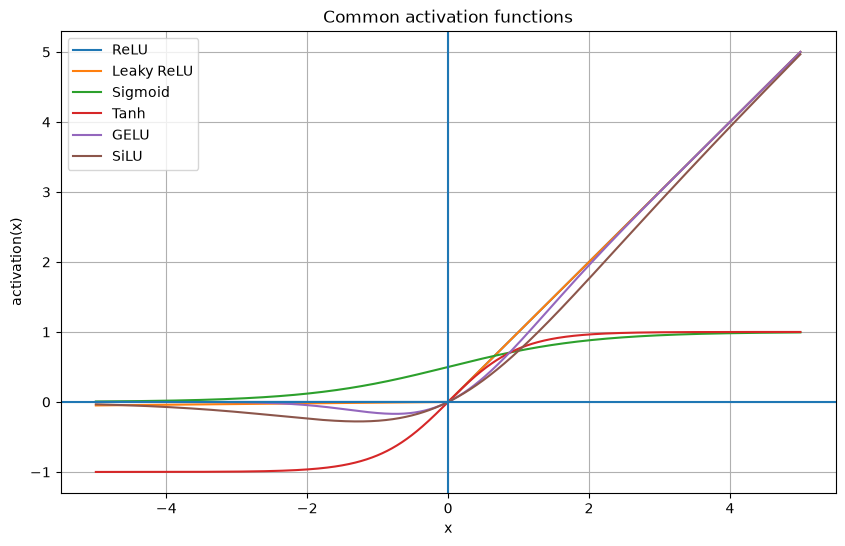

In [73]:
x_plot: torch.Tensor = torch.linspace(
    -5.0,
    5.0,
    steps=1000,
)

relu_y: torch.Tensor = relu_manual(x_plot)
leaky_relu_y: torch.Tensor = leaky_relu_manual(x_plot)
sigmoid_y: torch.Tensor = sigmoid_manual(x_plot)
tanh_y: torch.Tensor = tanh_manual(x_plot)
gelu_y: torch.Tensor = gelu_exact_manual(x_plot)
silu_y: torch.Tensor = silu_manual(x_plot)

plt.figure(figsize=(10, 6))

plt.plot(x_plot.numpy(), relu_y.numpy(), label="ReLU")
plt.plot(x_plot.numpy(), leaky_relu_y.numpy(), label="Leaky ReLU")
plt.plot(x_plot.numpy(), sigmoid_y.numpy(), label="Sigmoid")
plt.plot(x_plot.numpy(), tanh_y.numpy(), label="Tanh")
plt.plot(x_plot.numpy(), gelu_y.numpy(), label="GELU")
plt.plot(x_plot.numpy(), silu_y.numpy(), label="SiLU")

plt.axhline(0.0)
plt.axvline(0.0)

plt.xlabel("x")
plt.ylabel("activation(x)")
plt.title("Common activation functions")
plt.legend()
plt.grid(True)

plt.show()

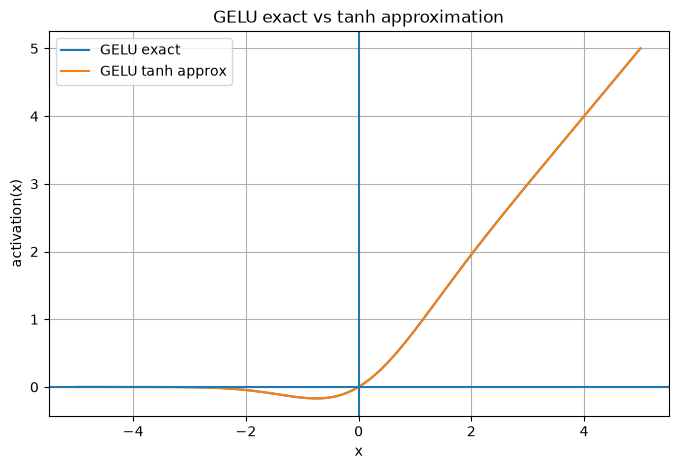

In [74]:
gelu_exact_y: torch.Tensor = gelu_exact_manual(x_plot)
gelu_approx_y: torch.Tensor = gelu_tanh_approx_manual(x_plot)

plt.figure(figsize=(8, 5))

plt.plot(
    x_plot.numpy(),
    gelu_exact_y.numpy(),
    label="GELU exact",
)
plt.plot(
    x_plot.numpy(),
    gelu_approx_y.numpy(),
    label="GELU tanh approx",
)

plt.axhline(0.0)
plt.axvline(0.0)

plt.xlabel("x")
plt.ylabel("activation(x)")
plt.title("GELU exact vs tanh approximation")
plt.legend()
plt.grid(True)

plt.show()

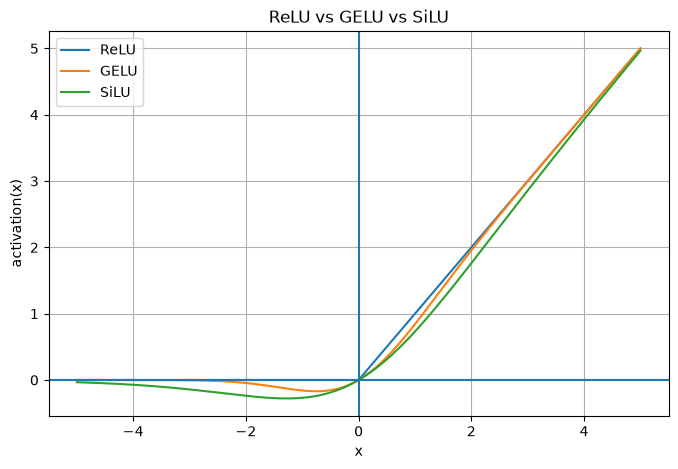

In [75]:
plt.figure(figsize=(8, 5))

plt.plot(
    x_plot.numpy(),
    relu_manual(x_plot).numpy(),
    label="ReLU",
)
plt.plot(
    x_plot.numpy(),
    gelu_exact_manual(x_plot).numpy(),
    label="GELU",
)
plt.plot(
    x_plot.numpy(),
    silu_manual(x_plot).numpy(),
    label="SiLU",
)

plt.axhline(0.0)
plt.axvline(0.0)

plt.xlabel("x")
plt.ylabel("activation(x)")
plt.title("ReLU vs GELU vs SiLU")
plt.legend()
plt.grid(True)

plt.show()

### What matters most for Transformers?

Historically, many neural networks used sigmoid or tanh.

In Transformer language models, the most relevant activations are:

- GELU,
- SiLU,
- gated SiLU variants such as SwiGLU.

ReLU is still important pedagogically because it is simple and helps
clarify what a nonlinear activation does.

However, modern LLM feed-forward networks more commonly use smooth
activations rather than hard-threshold activations.

## 5. Gated MLPs and SwiGLU

A standard feed-forward network applies one nonlinear transformation:

$$
\operatorname{FFN}(x)
=
W_{\text{down}}
\phi(
W_{\text{up}}x
).
$$

A gated feed-forward network introduces two parallel projections.

One branch produces content, while the other produces a gate that
controls how much of that content passes through.

A commonly used gated activation in modern language models is SwiGLU:

$$
\operatorname{SwiGLU}(x)
=
W_{\text{down}}
\left(
\operatorname{SiLU}
\left(
W_{\text{gate}}x
\right)
\odot
\left(
W_{\text{up}}x
\right)
\right).
$$

The symbol

$$
\odot
$$

denotes element-wise multiplication.

The computation therefore has three learned projections:

<pre>
             ┌─ W_gate → SiLU ─┐
x ───────────┤                  × ─→ W_down → output
             └─ W_up ──────────┘
</pre>

The two branches have the same hidden dimension so that their outputs
can be multiplied element by element.

In [76]:
embedding_dim: int = 4
hidden_dim: int = 8

x: torch.Tensor = torch.randn(
    2,
    3,
    embedding_dim,
)

gate_projection = nn.Linear(
    embedding_dim,
    hidden_dim,
    bias=False,
)

up_projection = nn.Linear(
    embedding_dim,
    hidden_dim,
    bias=False,
)

down_projection = nn.Linear(
    hidden_dim,
    embedding_dim,
    bias=False,
)

In [77]:
gate: torch.Tensor = gate_projection(x)
content: torch.Tensor = up_projection(x)

print("x:", x.shape)
print("gate:", gate.shape)
print("content:", content.shape)

x: torch.Size([2, 3, 4])
gate: torch.Size([2, 3, 8])
content: torch.Size([2, 3, 8])


In [78]:
activated_gate: torch.Tensor = F.silu(gate)

hidden: torch.Tensor = activated_gate * content

print(activated_gate.shape)
print(hidden.shape)

torch.Size([2, 3, 8])
torch.Size([2, 3, 8])


In [79]:
gate_values: torch.Tensor = torch.tensor([-3.0, -1.0, 0.0, 1.0, 3.0])

content_values: torch.Tensor = torch.ones_like(gate_values)

result: torch.Tensor = F.silu(gate_values) * content_values

print("gate:", gate_values)
print("SiLU(gate):", F.silu(gate_values))
print("result:", result)

gate: tensor([-3., -1.,  0.,  1.,  3.])
SiLU(gate): tensor([-0.1423, -0.2689,  0.0000,  0.7311,  2.8577])
result: tensor([-0.1423, -0.2689,  0.0000,  0.7311,  2.8577])


### The Gate Is Not Binary

The word "gate" does not mean that a feature is simply switched on or
off.

In SwiGLU,

$$
\operatorname{SiLU}(x)
=
x\sigma(x),
$$

so the gate is a continuous learned modulation.

It can suppress, preserve, amplify, or change the sign of different
hidden features.

In [80]:
output: torch.Tensor = down_projection(hidden)

print(output.shape)

torch.Size([2, 3, 4])


In [81]:
class SwiGLU(nn.Module):
    def __init__(self, embedding_dim, hidden_dim):
        super().__init__()

        self.gate_projection = nn.Linear(embedding_dim, hidden_dim, bias=False)

        self.up_projection = nn.Linear(embedding_dim, hidden_dim, bias=False)

        self.down_projection = nn.Linear(hidden_dim, embedding_dim, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gate: torch.Tensor = F.silu(self.gate_projection(x))

        content: torch.Tensor = self.up_projection(x)

        hidden: torch.Tensor = gate * content

        return self.down_projection(hidden)


In [82]:
swiglu = SwiGLU(
    embedding_dim=8,
    hidden_dim=24,
)

x: torch.Tensor = torch.randn(
    2,
    5,
    8,
)

output: torch.Tensor = swiglu(x)

print("input:", x.shape)
print("output:", output.shape)

input: torch.Size([2, 5, 8])
output: torch.Size([2, 5, 8])


In [83]:
def count_parameters(
    module: nn.Module,
) -> int:
    return sum(parameter.numel() for parameter in module.parameters())


embedding_dim: int = 120
standard_hidden_dim: int = 4 * embedding_dim

standard_ffn = FeedForward(
    embedding_dim=embedding_dim,
    hidden_dim=standard_hidden_dim,
)


swiglu_hidden_dim: int = round(8 * embedding_dim / 3)

swiglu = SwiGLU(
    embedding_dim=embedding_dim,
    hidden_dim=swiglu_hidden_dim,
)

print(
    "standard FFN:",
    count_parameters(standard_ffn),
)

print(
    "SwiGLU:",
    count_parameters(swiglu),
)

standard FFN: 115800
SwiGLU: 115200


## 6. Pre-Norm vs Post-Norm

A Transformer block combines three important ideas:

- a transformation such as attention or an MLP,
- normalization,
- a residual connection.

However, normalization can be placed in different locations relative to
the transformation and residual path.

Two common arrangements are **Post-Norm** and **Pre-Norm**.

### Post-Norm

The original Transformer formulation applies the transformation first,
adds the residual connection, and then normalizes:

$$
y
=
\operatorname{Norm}
\left(
x + F(x)
\right).
$$

### Pre-Norm

A Pre-Norm block normalizes the input before the transformation:

$$
y
=
x
+
F(
\operatorname{Norm}(x)
).
$$

The residual stream therefore bypasses the transformation and
normalization directly.

The two designs contain similar components but create different
gradient paths through deep networks.

In [84]:
class PreNormResidual(nn.Module):
    def __init__(
        self,
        embedding_dim: int,
        transformation: nn.Module,
    ) -> None:
        super().__init__()

        self.norm = nn.RMSNorm(embedding_dim)
        self.transformation = transformation

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        return x + self.transformation(self.norm(x))


class PostNormResidual(nn.Module):
    def __init__(
        self,
        embedding_dim: int,
        transformation: nn.Module,
    ) -> None:
        super().__init__()

        self.norm = nn.RMSNorm(embedding_dim)
        self.transformation = transformation

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        return self.norm(x + self.transformation(x))

### Gradient Paths

For Pre-Norm,

$$
y=x+F(N(x)),
$$

so

$$
\frac{\partial y}{\partial x}
=
I
+
J_F J_N.
$$

The identity term provides a direct gradient path through the residual
stream.

For Post-Norm,

$$
y=N(x+F(x)),
$$

so

$$
\frac{\partial y}{\partial x}
=
J_N
\left(
I+J_F
\right).
$$

The residual contribution still exists, but gradients pass through the
normalization Jacobian before reaching the previous residual stream.

This difference becomes increasingly important as many Transformer
blocks are stacked.

## 7. Pre-Norm Transformer Block Structure

A Pre-Norm Transformer block contains two residual sublayers.

First, self-attention:

$$
x'
=
x
+
\operatorname{Attention}
\left(
\operatorname{Norm}_1(x)
\right).
$$

Then, the feed-forward network:

$$
y
=
x'
+
\operatorname{FFN}
\left(
\operatorname{Norm}_2(x')
\right).
$$

Both transformations return tensors with the same model shape

$$
(B,T,C),
$$

which allows them to be added back to the residual stream.

The block can therefore be viewed as repeated updates to one persistent
representation:

<pre>
residual stream
      ↓
Norm → Attention
      ↓
     add
      ↓
residual stream
      ↓
Norm → FFN
      ↓
     add
      ↓
residual stream
</pre>

In [85]:
class PreNormTransformerBlock(nn.Module):
    def __init__(
        self,
        embedding_dim: int,
        attention: nn.Module,
        feed_forward: nn.Module,
    ) -> None:
        super().__init__()

        self.attention_norm = nn.RMSNorm(embedding_dim)

        self.attention = attention

        self.feed_forward_norm = nn.RMSNorm(embedding_dim)

        self.feed_forward = feed_forward

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        x = x + self.attention(self.attention_norm(x))

        x = x + self.feed_forward(self.feed_forward_norm(x))

        return x

## Takeaways

- Normalization operates independently on each token representation over
  the feature dimension.

- LayerNorm controls both the center and scale of a representation.

- RMSNorm controls its scale without subtracting the mean.

- Residual connections preserve an identity path:

  $$
  x \rightarrow x + F(x).
  $$

- Attention mixes information across token positions.

- Feed-forward networks transform features independently within each
  token.

- Nonlinear activation functions are necessary because stacked linear
  transformations alone collapse into another linear transformation.

- GELU and SiLU provide smooth nonlinear transformations commonly used
  in Transformer models.

- SwiGLU uses two parallel projections:

  $$
  \operatorname{SiLU}(W_{\text{gate}}x)
  \odot
  W_{\text{up}}x.
  $$

- Gated MLPs require different hidden-width choices when parameter-count
  comparisons are intended to remain fair.

- Pre-Norm applies normalization before each Transformer sublayer:

  $$
  x
  \leftarrow
  x + F(\operatorname{Norm}(x)).
  $$

- Post-Norm applies normalization after the residual addition.

- A Transformer block can be understood as a sequence of learned updates
  to a persistent residual stream of shape

  $$
  (B,T,C).
  $$